# Classification Photo vs Non-Photo - Version Simplifiée

Notebook nettoyé et optimisé pour la classification binaire d'images.

## Exécution
**Exécutez toutes les cellules dans l'ordre (Run All)**

## 1. Imports et Configuration

In [43]:
import os
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Configuration
tf.keras.utils.set_random_seed(42)
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 20
DATA_DIR = "/workspace/data/raw"

print(f"✅ TensorFlow {tf.__version__}")
print(f"✅ GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ TensorFlow 2.20.0
✅ GPU disponible: True


## 2. Chargement des Données avec Équilibrage

In [44]:
# Chargement datasets
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

class_names = train_ds.class_names
print(f"\n✅ Classes: {class_names}")

# Optimisation pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 41398 files belonging to 2 classes.
Using 33119 files for training.
Found 41398 files belonging to 2 classes.
Using 8279 files for validation.

✅ Classes: ['Photos', 'non_photo']


## 3. Augmentation et Normalisation

In [45]:
# Augmentation des données
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
], name="augmentation")

# Normalisation
normalization = keras.layers.Rescaling(1./255)

## 4. Construction du Modèle CNN

Architecture simple et efficace avec normalisation intégrée.

In [46]:
def create_model():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    # Augmentation (seulement pendant l'entraînement)
    x = data_augmentation(inputs)
    
    # Normalisation (TOUJOURS appliquée)
    x = normalization(x)
    
    # CNN
    x = keras.layers.Conv2D(32, 3, activation='relu')(x)
    x = keras.layers.MaxPooling2D(2)(x)
    x = keras.layers.Conv2D(64, 3, activation='relu')(x)
    x = keras.layers.MaxPooling2D(2)(x)
    x = keras.layers.Conv2D(128, 3, activation='relu')(x)
    x = keras.layers.GlobalAveragePooling2D()(x)
    # x = keras.layers.Flatten()(x)
    # Classification
    x = keras.layers.Dense(128, activation='relu')(x)
    x = keras.layers.Dropout(0.5)(x)
    outputs = keras.layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs)
    return model

model = create_model()

# Compilation
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Calcul des Poids de Classe

In [47]:
# Compter les échantillons par classe
class_0_count = 0
class_1_count = 0

for _, labels in train_ds:
    class_0_count += np.sum(labels.numpy() == 0)
    class_1_count += np.sum(labels.numpy() == 1)

total = class_0_count + class_1_count
print(f"Classe {class_names[0]}: {class_0_count}")
print(f"Classe {class_names[1]}: {class_1_count}")

# Calcul des poids
weight_for_0 = (1 / class_0_count) * (total / 2.0)
weight_for_1 = (1 / class_1_count) * (total / 2.0)
class_weights = {0: weight_for_0, 1: weight_for_1}

print(f"\nPoids de classe: {class_weights}")

2025-10-03 12:54:12.953254: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


Classe Photos: 7997
Classe non_photo: 25122

Poids de classe: {0: np.float64(2.0707140177566585), 1: np.float64(0.6591632831780908)}


## 6. Entraînement

In [48]:
# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

# Entraînement
print(" Début de l'entraînement...\n")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

print(" Entraînement terminé!")

 Début de l'entraînement...

Epoch 1/20
1033/1035 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6955 - loss: 0.5559

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


1035/1035 ━━━━━━━━━━━━━━━━━━━━ 35s 32ms/step - accuracy: 0.7157 - loss: 0.4879 - val_accuracy: 0.7338 - val_loss: 0.4635 - learning_rate: 1.0000e-04
Epoch 2/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.7516 - loss: 0.4118 - val_accuracy: 0.7467 - val_loss: 0.4290 - learning_rate: 1.0000e-04
Epoch 3/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.7610 - loss: 0.3940 - val_accuracy: 0.7474 - val_loss: 0.4462 - learning_rate: 1.0000e-04
Epoch 4/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.7709 - loss: 0.3827 - val_accuracy: 0.7697 - val_loss: 0.4202 - learning_rate: 1.0000e-04
Epoch 5/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.7794 - loss: 0.3743 - val_accuracy: 0.7672 - val_loss: 0.4349 - learning_rate: 1.0000e-04
Epoch 6/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.7853 - loss: 0.3673 - val_accuracy: 0.7710 - val_loss: 0.4230 - learning_rate: 1.0000e-04
Epoch 7/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/

## 7. Courbes d'Apprentissage

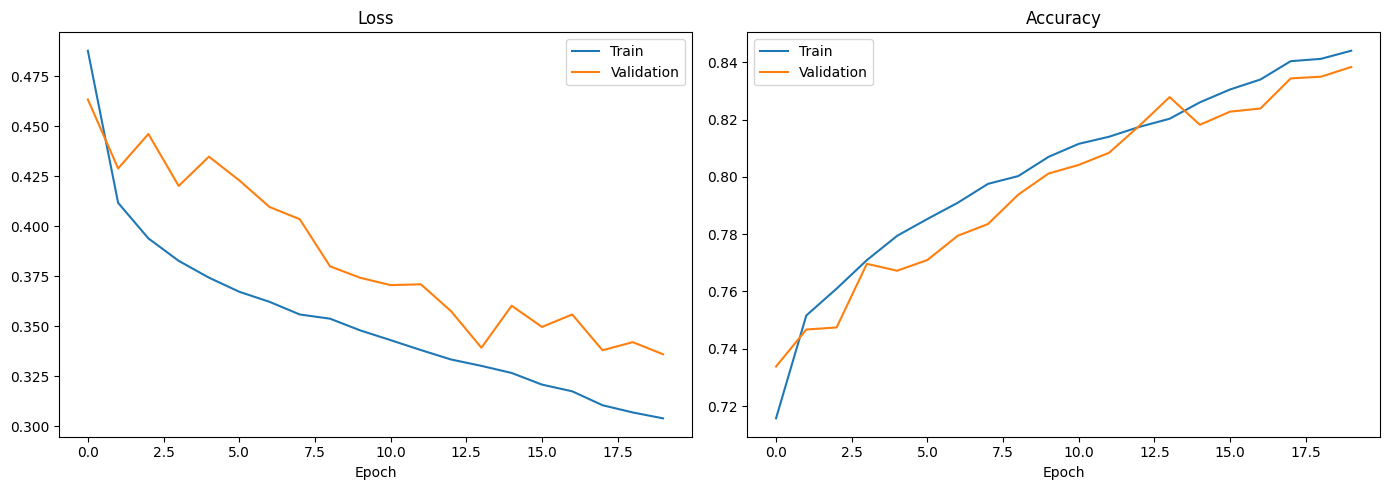

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history.history['loss'], label='Train')
ax1.plot(history.history['val_loss'], label='Validation')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

# Accuracy
ax2.plot(history.history['accuracy'], label='Train')
ax2.plot(history.history['val_accuracy'], label='Validation')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

## 8. Évaluation

259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


2025-10-03 13:03:43.206615: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


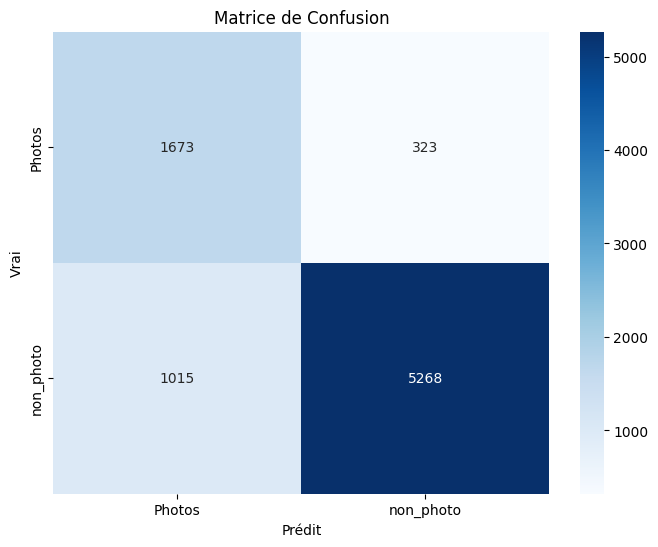


              precision    recall  f1-score   support

      Photos       0.62      0.84      0.71      1996
   non_photo       0.94      0.84      0.89      6283

    accuracy                           0.84      8279
   macro avg       0.78      0.84      0.80      8279
weighted avg       0.87      0.84      0.85      8279



In [50]:
# Prédictions
y_pred_proba = model.predict(val_ds)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion')
plt.ylabel('Vrai')
plt.xlabel('Prédit')
plt.show()

# Rapport
print("\n" + classification_report(y_true, y_pred, target_names=class_names))

## 9. Test sur Image Unique

**⚠️ IMPORTANT:** Ne PAS normaliser manuellement - le modèle le fait automatiquement!

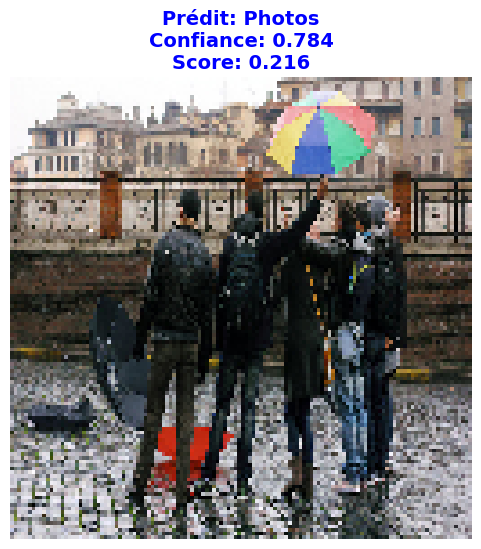

Image: /workspace/data/raw/Photos/photo_0012.jpg
Score brut: 0.2156
Prédiction: Photos
Confiance: 0.7844


(np.float32(0.21560958), 'Photos')

In [51]:
def test_single_image(image_path, threshold=0.5):
    """Teste une seule image - PAS de normalisation manuelle!"""
    from tensorflow.keras.preprocessing import image as keras_image
    
    # Charger l'image (pixels 0-255)
    img = keras_image.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = keras_image.img_to_array(img)  # Shape: (128, 128, 3)
    img_array = np.expand_dims(img_array, axis=0)  # Shape: (1, 128, 128, 3)
    
    # NE PAS DIVISER PAR 255 - le modèle s'en charge!
    
    # Prédiction
    proba = model.predict(img_array, verbose=0)[0][0]
    predicted_class = class_names[1] if proba >= threshold else class_names[0]
    confidence = proba if proba >= threshold else 1 - proba
    
    # Affichage
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    color = 'green' if proba >= threshold else 'blue'
    plt.title(f"Prédit: {predicted_class}\nConfiance: {confidence:.3f}\nScore: {proba:.3f}", 
              color=color, fontsize=14, weight='bold')
    plt.show()
    
    print(f"Image: {image_path}")
    print(f"Score brut: {proba:.4f}")
    print(f"Prédiction: {predicted_class}")
    print(f"Confiance: {confidence:.4f}")
    
    return proba, predicted_class

# TEST
test_image_path = "/workspace/data/raw/Photos/photo_0012.jpg"
test_single_image(test_image_path)

## 10. Test Multiple


=== TEST SUR 5 PHOTOS ===


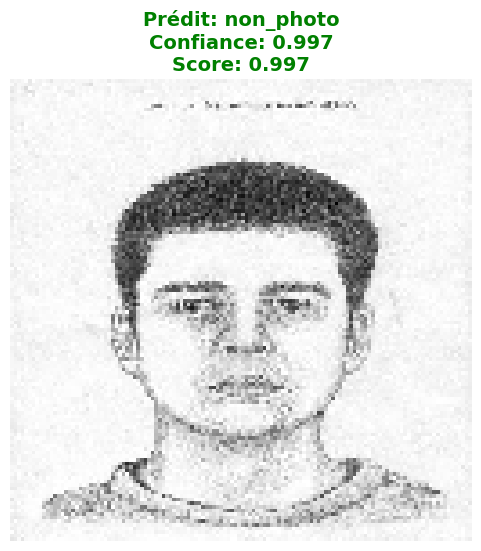

Image: /workspace/data/raw/non_photo/000_1_1_sz1.jpg
Score brut: 0.9973
Prédiction: non_photo
Confiance: 0.9973
✅ 000_1_1_sz1.jpg: non_photo (0.997)



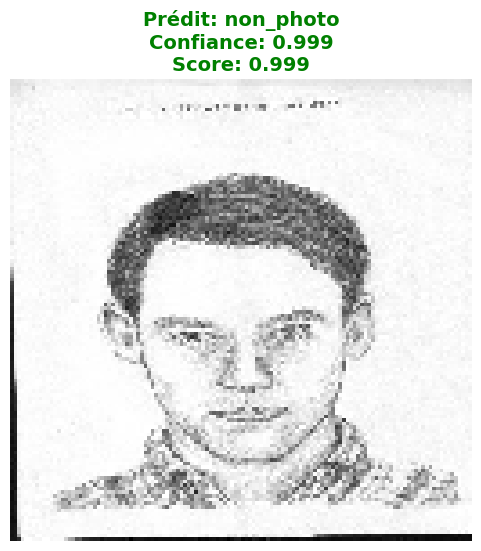

Image: /workspace/data/raw/non_photo/001_1_1_sz1.jpg
Score brut: 0.9990
Prédiction: non_photo
Confiance: 0.9990
✅ 001_1_1_sz1.jpg: non_photo (0.999)



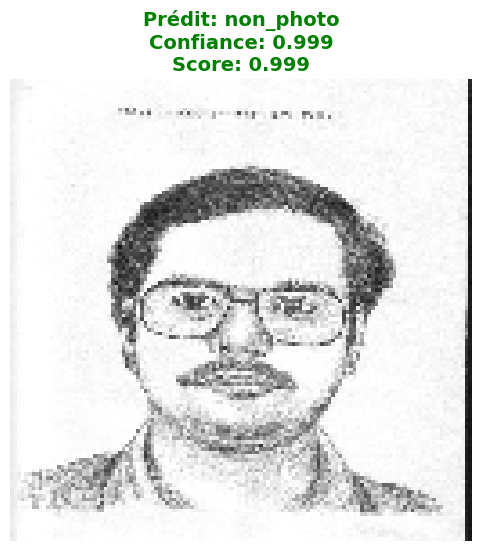

Image: /workspace/data/raw/non_photo/002_1_1_sz1.jpg
Score brut: 0.9991
Prédiction: non_photo
Confiance: 0.9991
✅ 002_1_1_sz1.jpg: non_photo (0.999)



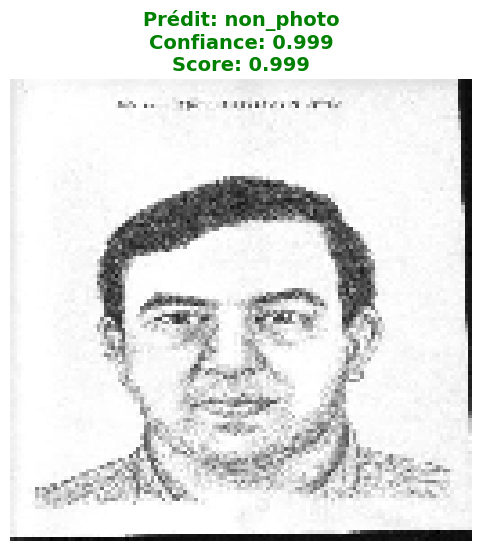

Image: /workspace/data/raw/non_photo/003_1_1_sz1.jpg
Score brut: 0.9987
Prédiction: non_photo
Confiance: 0.9987
✅ 003_1_1_sz1.jpg: non_photo (0.999)



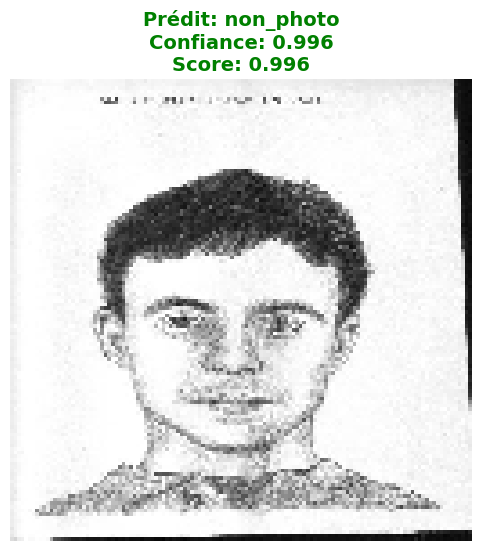

Image: /workspace/data/raw/non_photo/004_1_1_sz1.jpg
Score brut: 0.9955
Prédiction: non_photo
Confiance: 0.9955
✅ 004_1_1_sz1.jpg: non_photo (0.996)



In [52]:
import glob

# Tester 5 photos
photo_dir = "/workspace/data/raw/non_photo"
photos = glob.glob(f"{photo_dir}/*.jpg")[:5]

print("\n=== TEST SUR 5 PHOTOS ===")
for photo in photos:
    proba, pred = test_single_image(photo)
    status = "✅" if pred == "non_photo" else "❌"
    print(f"{status} {os.path.basename(photo)}: {pred} ({proba:.3f})\n")

## 11. Sauvegarde

In [53]:
model.save('/workspace/outputs/photo_classifier_clean.keras')
print("✅ Modèle sauvegardé")

✅ Modèle sauvegardé
